# **Simulación de las EDO y $\mathcal{R}_0$ con `simulate()`**

$\mathcal{R}_0$ es un umbral: si $\mathcal{R}_0 < 1$ la infección introducida cerca del equilibrio libre de infección (DFE) se extingue, y si $\mathcal{R}_0 > 1$ invade. `model.simulate()` integra el sistema de EDO para ver ese comportamiento:

* Los parámetros indicados en `values={...}` quedan **fijos**. Los demás se **sortean al azar**: log-uniformes en `default_range` (por defecto $[0.01, 1]$), o en su propio rango con `ranges={...}`.
* `n_runs` genera varias simulaciones, y `R0_range` conserva solo los sorteos con $\mathcal{R}_0$ en un rango, por ejemplo `(1, None)` para $\mathcal{R}_0 > 1$.
* Por defecto, los compartimentos no infectados parten del DFE y los infectados de una perturbación pequeña (`perturbation`, 1 % del total). Con `initial={...}` se dan las condiciones iniciales.
* Cada simulación guarda sus parámetros, su condición inicial, su $\mathcal{R}_0$ y su DFE.

Los gráficos se editan con argumentos de `plot()` y `plot_phase()`:

| Argumento | Para qué |
|---|---|
| `variables` | variables que se grafican |
| `title`, `titles` | título (`"{R0}"` se reemplaza por su valor) y título de cada panel |
| `xlabel`, `ylabel` | nombres de los ejes (admiten LaTeX entre `$...$`) |
| `labels`, `colors`, `linestyles` | por variable: diccionario, lista o un solo valor |
| `linewidth`, `alpha` | grosor y opacidad de las líneas |
| `legend`, `legend_kw` | mostrar u ocultar la leyenda, su ubicación y otras opciones |
| `figsize`, `subplots`, `ncols` | tamaño de la figura y un panel por variable |
| `logy`, `logx`, `xlim`, `ylim`, `grid` | escalas, límites y grilla |
| `color_by_R0` | colorear cada simulación según $\mathcal{R}_0 < 1$ o $\mathcal{R}_0 > 1$ |
| `show_dfe` | línea horizontal en el valor del DFE |
| `ax` | dibujar sobre ejes existentes, para comparar escenarios |
| `save`, `dpi` | guardar la figura (aquí, en `outputs/`) |

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yvan-BM-Git/pyR0compute/blob/main/examples/06_simulaciones.ipynb)

In [1]:
%pip install pyR0compute                      # Instala la librería pyR0compute desde PyPI

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os                                     # Carpeta para guardar las figuras
import warnings                               # Avisos de la librería
import numpy as np                            # Cálculo numérico
import sympy as sp                            # Cálculo simbólico
import matplotlib.pyplot as plt               # Gráficos
from pyr0compute import R0Model               # Clase principal de la librería
from pyr0compute.simulation import PALETTE    # Colores de la librería (orden fijo)

os.makedirs("outputs", exist_ok=True)         # Las figuras se guardan en outputs/

## 1. SIR con dinámica vital: $\mathcal{R}_0 < 1$ frente a $\mathcal{R}_0 > 1$

$$
\dot S = \Lambda - \beta S I - \mu S, \qquad
\dot I = \beta S I - (\gamma + \mu) I, \qquad
\dot R = \gamma I - \mu R, \qquad
\mathcal{R}_0 = \frac{\Lambda\beta}{\mu(\gamma+\mu)}.
$$

Con $\mathcal{R}_0 > 1$ la solución converge al equilibrio endémico $S^\dagger = (\gamma+\mu)/\beta$, $I^\dagger = \Lambda/(\gamma+\mu) - \mu/\beta$. Las líneas discontinuas (`show_dfe=True`) marcan el DFE $S^* = \Lambda/\mu$.

In [3]:
sir = R0Model('''
    dS/dt = Lambda - beta*S*I - mu*S
    dI/dt = beta*S*I - (gamma + mu)*I
    dR/dt = gamma*I - mu*R
''', infected=["I"])
print("R0 =", sir.R0)

base = dict(Lambda=10, mu=0.1, gamma=0.5)          # parámetros fijos
bajo = sir.simulate((0, 200), values=dict(base, beta=0.002))
alto = sir.simulate((0, 200), values=dict(base, beta=0.01))
print(bajo)
print(alto)
print("Condición inicial (DFE + perturbación):", alto.initial)

beta = 0.01
print(f"\nEstado final con R0 > 1: S = {alto.final()['S']:.4f}, I = {alto.final()['I']:.4f}")
print(f"Equilibrio endémico:     S = {(base['gamma'] + base['mu']) / beta:.4f}, "
      f"I = {base['Lambda'] / (base['gamma'] + base['mu']) - base['mu'] / beta:.4f}")

R0 = Lambda*beta/(mu*(gamma + mu))


SimulationResult(1 run, R0 = 0.3333, t in [0, 200])
SimulationResult(1 run, R0 = 1.667, t in [0, 200])
Condición inicial (DFE + perturbación): {'S': 100.0, 'I': 1.0, 'R': 0.0}

Estado final con R0 > 1: S = 60.0000, I = 6.6667
Equilibrio endémico:     S = 60.0000, I = 6.6667


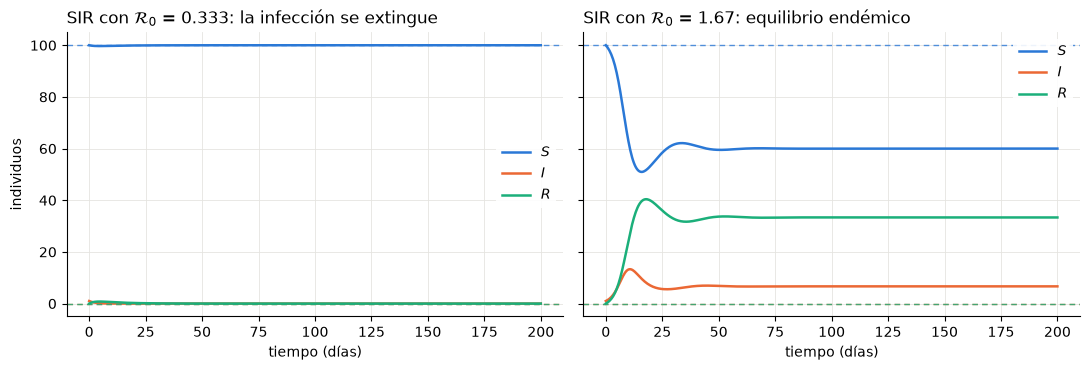

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
bajo.plot(ax=axes[0], title=r"SIR con $\mathcal{R}_0$ = {R0}: la infección se extingue", show_dfe=True,
          xlabel="tiempo (días)", ylabel="individuos")
alto.plot(ax=axes[1], title=r"SIR con $\mathcal{R}_0$ = {R0}: equilibrio endémico", show_dfe=True,
          xlabel="tiempo (días)")
fig.tight_layout()
fig.savefig("outputs/06_sir_R0_menor_y_mayor_que_1.png", dpi=200, bbox_inches="tight")

### Personalización de una figura

Variables seleccionadas, nombres, colores, tipos de línea, escala logarítmica, límites, leyenda y tamaño:

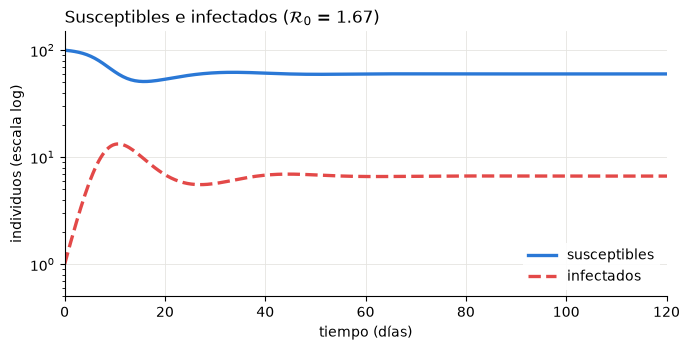

In [5]:
alto.plot(["S", "I"],
          title=r"Susceptibles e infectados ($\mathcal{R}_0$ = {R0})",
          xlabel="tiempo (días)", ylabel="individuos (escala log)",
          labels={"S": "susceptibles", "I": "infectados"},
          colors={"S": PALETTE[0], "I": PALETTE[7]},
          linestyles={"S": "-", "I": "--"}, linewidth=2.4,
          logy=True, ylim=(0.5, 150), xlim=(0, 120),
          legend="lower right", figsize=(7, 3.6),
          save="outputs/06_sir_personalizado.png");

## 2. Parámetros aleatorios por defecto

Sin `values`, todos los parámetros se sortean. `seed` hace el sorteo reproducible, y `summary()` muestra los valores usados y el $\mathcal{R}_0$ de cada simulación.

In [6]:
azar = sir.simulate((0, 100), n_runs=4, seed=7)
print(azar)
azar.summary()

SimulationResult(4 runs, R0 < 1 in 2, R0 > 1 in 2, t in [0, 100])


,R0,Lambda,beta,gamma,mu
run,,,,,
0,10.226040,0.177906,0.622913,0.355936,0.028211
1,0.112851,0.039841,0.558608,0.010245,0.438992
2,12.301916,0.392770,0.086272,0.040371,0.036046
3,0.085324,0.032340,0.077652,0.102117,0.127937


## 3. Parámetros fijos y aleatorios: conjunto de simulaciones

Fijamos $\Lambda$, $\mu$ y $\gamma$, y sorteamos $\beta$ en $[0.001, 0.02]$. Cada simulación se colorea según su $\mathcal{R}_0$ (`color_by_R0`, activo por defecto con varias corridas). Las que tienen $\mathcal{R}_0 < 1$ vuelven al DFE; las que tienen $\mathcal{R}_0 > 1$ se alejan de él hacia un equilibrio endémico.

SimulationResult(40 runs, R0 < 1 in 26, R0 > 1 in 14, t in [0, 200])


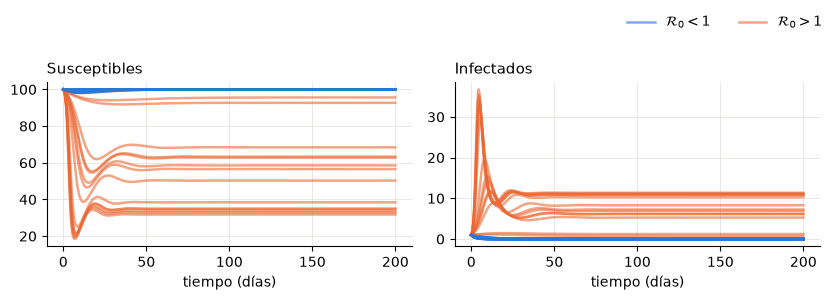

In [7]:
conjunto = sir.simulate((0, 200), values=base, ranges={"beta": (0.001, 0.02)}, n_runs=40, seed=1)
print(conjunto)
conjunto.plot(["S", "I"], subplots=True, ncols=2, xlabel="tiempo (días)",
              titles={"S": "Susceptibles", "I": "Infectados"},
              save="outputs/06_sir_conjunto_por_R0.png");

El plano de fase muestra lo mismo: desde el DFE (✕), las trayectorias con $\mathcal{R}_0 > 1$ giran en espiral hacia un equilibrio endémico. Con `n_points` mayor las curvas se ven más suaves.

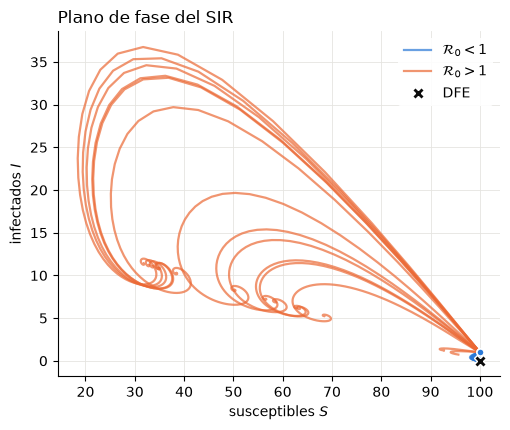

In [8]:
conjunto.plot_phase("S", "I", title="Plano de fase del SIR", xlabel="susceptibles $S$",
                    ylabel="infectados $I$", save="outputs/06_sir_plano_de_fase.png");

### Solo $\mathcal{R}_0 > 1$ o solo $\mathcal{R}_0 < 1$

`R0_range` conserva solo los sorteos que cumplen la condición.

R0 > 1: [4.03 1.74 2.88 2.18 1.5  2.29 1.98 7.34 2.41 1.23 5.44 3.46 6.2  1.05
 2.51]
R0 < 1: [0.46 0.54 0.24 0.35 0.21 0.49 0.3  0.91 0.87 0.77 0.35 0.65 0.58 0.25
 0.25]


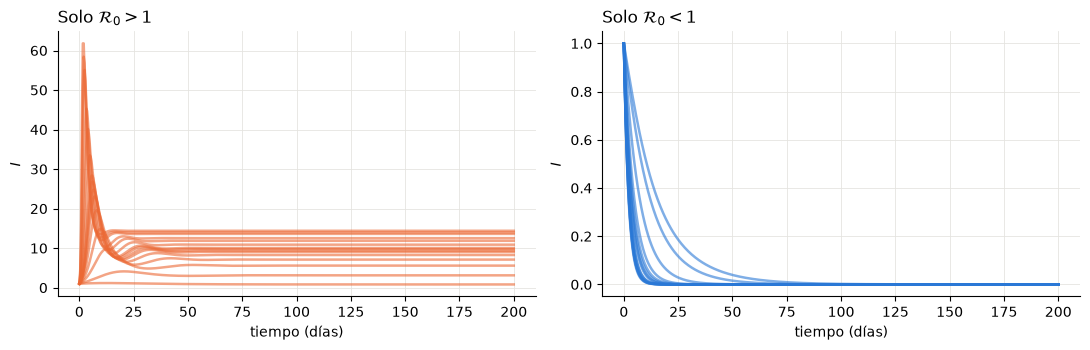

In [9]:
mayores = sir.simulate((0, 200), values=base, ranges={"beta": (0.001, 0.05)}, R0_range=(1, None),
                       n_runs=15, seed=2)
menores = sir.simulate((0, 200), values=base, ranges={"beta": (0.001, 0.05)}, R0_range=(None, 1),
                       n_runs=15, seed=2)
print("R0 > 1:", np.round(mayores.R0_values, 2))
print("R0 < 1:", np.round(menores.R0_values, 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
mayores.plot("I", ax=axes[0], title=r"Solo $\mathcal{R}_0 > 1$", xlabel="tiempo (días)", legend=False)
menores.plot("I", ax=axes[1], title=r"Solo $\mathcal{R}_0 < 1$", xlabel="tiempo (días)", legend=False)
fig.tight_layout()
fig.savefig("outputs/06_sir_R0_range.png", dpi=200, bbox_inches="tight")

## 4. Bifurcación transcrítica en $\mathcal{R}_0 = 1$

Para cada $\beta$ simulamos hasta el estado estacionario y graficamos $I$ final frente a $\mathcal{R}_0$. Para $\mathcal{R}_0 \le 1$ el único equilibrio estable es el DFE ($I = 0$); para $\mathcal{R}_0 > 1$ es el endémico, $I^\dagger = \frac{\Lambda}{\gamma+\mu}\left(1 - \frac{1}{\mathcal{R}_0}\right)$.

Máxima diferencia con la teoría: 1.8030021919912542e-13


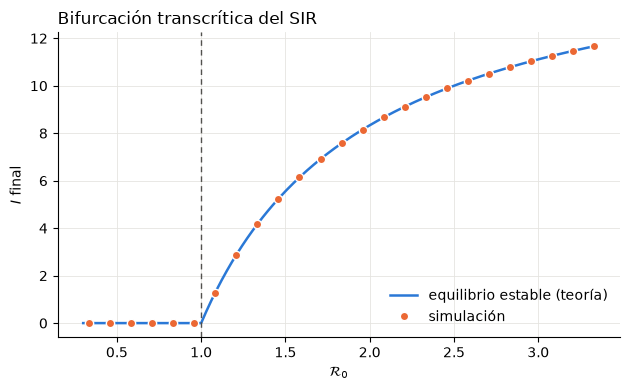

In [10]:
betas = np.linspace(0.002, 0.02, 25)
R0s, I_final = [], []
for b in betas:
    r = sir.simulate((0, 2000), values=dict(base, beta=b), n_points=200)
    R0s.append(r.R0)
    I_final.append(r.final()["I"])
R0s, I_final = np.array(R0s), np.array(I_final)

curva = np.linspace(0.3, R0s.max(), 300)
teoria = np.where(curva > 1, base["Lambda"] / (base["gamma"] + base["mu"]) * (1 - 1 / curva), 0)

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(curva, teoria, color=PALETTE[0], linewidth=1.8, label="equilibrio estable (teoría)")
ax.plot(R0s, I_final, "o", color=PALETTE[1], markersize=6, markeredgecolor="white", label="simulación")
ax.axvline(1, color="#52514e", linewidth=1, linestyle=(0, (4, 3)))
ax.set_xlabel(r"$\mathcal{R}_0$")
ax.set_ylabel(r"$I$ final")
ax.set_title("Bifurcación transcrítica del SIR", loc="left")
ax.grid(True, color="#e5e4e0", linewidth=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("outputs/06_sir_bifurcacion_transcritica.png", dpi=200, bbox_inches="tight")
print("Máxima diferencia con la teoría:", np.max(np.abs(I_final - np.where(R0s > 1, base["Lambda"] / 0.6 * (1 - 1 / R0s), 0))))

### Cerca del umbral: convergencia lenta

Cerca del DFE, $\dot I \approx (\gamma+\mu)(\mathcal{R}_0 - 1)\, I$. Con $\mathcal{R}_0 < 1$, $I$ decae exponencialmente con tasa $(\gamma+\mu)(1 - \mathcal{R}_0)$: en escala logarítmica es una recta, tanto menos inclinada cuanto más cerca de 1 está $\mathcal{R}_0$. Con $\mathcal{R}_0 > 1$, el nivel endémico $I^\dagger \propto 1 - 1/\mathcal{R}_0$ también tiende a 0 cuando $\mathcal{R}_0 \to 1$.

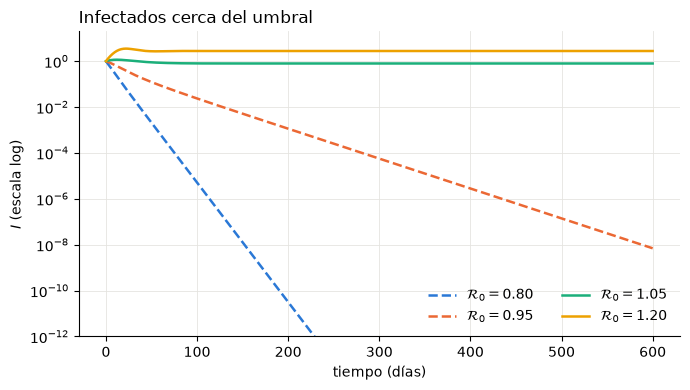

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
for k, R0_obj in enumerate([0.8, 0.95, 1.05, 1.2]):
    b = R0_obj * base["mu"] * (base["gamma"] + base["mu"]) / base["Lambda"]
    r = sir.simulate((0, 600), values=dict(base, beta=b))
    r.plot("I", ax=ax, colors=PALETTE[k], labels=rf"$\mathcal{{R}}_0 = {r.R0:.2f}$",
           linestyles="-" if r.R0 > 1 else "--", logy=True, ylim=(1e-12, 20), title="Infectados cerca del umbral",
           xlabel="tiempo (días)", ylabel="$I$ (escala log)", legend=False)
ax.legend(frameon=False, ncol=2)
fig.savefig("outputs/06_sir_cerca_del_umbral.png", dpi=200, bbox_inches="tight")

## 5. SEIR con vacunación: comparar escenarios en los mismos ejes

Una fracción $p$ de los nacimientos se vacuna ($W$):
$$
\dot S = (1-p)\Lambda - \beta S I - \mu S, \quad \dot W = p\Lambda - \mu W, \quad
\dot E = \beta S I - (\sigma+\mu) E, \quad \dot I = \sigma E - (\gamma+\mu) I, \quad \dot R = \gamma I - \mu R.
$$
$\mathcal{R}_0(p) = (1-p)\,\mathcal{R}_0(0)$, de modo que la cobertura crítica es $p_c = 1 - 1/\mathcal{R}_0(0)$.

R0 = -Lambda*beta*sigma*(p - 1)/(mu*(gamma + mu)*(mu + sigma))
R0 sin vacuna = 7.576; cobertura crítica p_c = 0.868


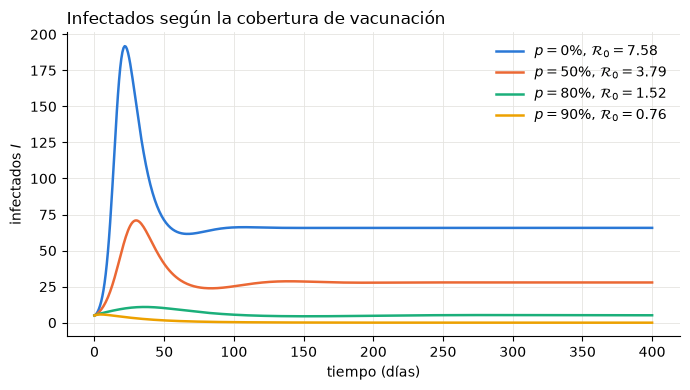

In [12]:
vacuna = R0Model('''
    dS/dt = (1 - p)*Lambda - beta*S*I - mu*S
    dW/dt = p*Lambda - mu*W
    dE/dt = beta*S*I - (sigma + mu)*E
    dI/dt = sigma*E - (gamma + mu)*I
    dR/dt = gamma*I - mu*R
''', infected=["E", "I"])
print("R0 =", sp.factor(vacuna.R0))

v = dict(Lambda=10, beta=0.002, mu=0.02, sigma=0.2, gamma=0.1)
R0_sin = vacuna.R0_numeric(dict(v, p=0))
print(f"R0 sin vacuna = {R0_sin:.3f}; cobertura crítica p_c = {1 - 1 / R0_sin:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
for k, p in enumerate([0.0, 0.5, 0.8, 0.9]):
    r = vacuna.simulate((0, 400), values=dict(v, p=p))
    r.plot("I", ax=ax, colors=PALETTE[k], labels=rf"$p = {p:.0%}$, $\mathcal{{R}}_0 = {r.R0:.2f}$".replace("%", r"\%"),
           title="Infectados según la cobertura de vacunación", xlabel="tiempo (días)",
           ylabel="infectados $I$", legend=False)
ax.legend(frameon=False)
fig.savefig("outputs/06_seir_vacunacion.png", dpi=200, bbox_inches="tight")

## 6. Modelo intrahuésped células blanco, infectadas y virus

$$
\dot T = s - dT - \beta T V, \quad \dot I = \beta T V - \delta I, \quad \dot V = pI - cV, \qquad
\mathcal{R}_0 = \frac{\beta p s}{c\, d\, \delta}.
$$

Con $\mathcal{R}_0 = 2$ se establece una infección crónica y con $\mathcal{R}_0 = 0.5$ el virus se elimina. La carga viral se ve mejor en escala logarítmica.

R0 = beta*p*s/(c*d*delta)


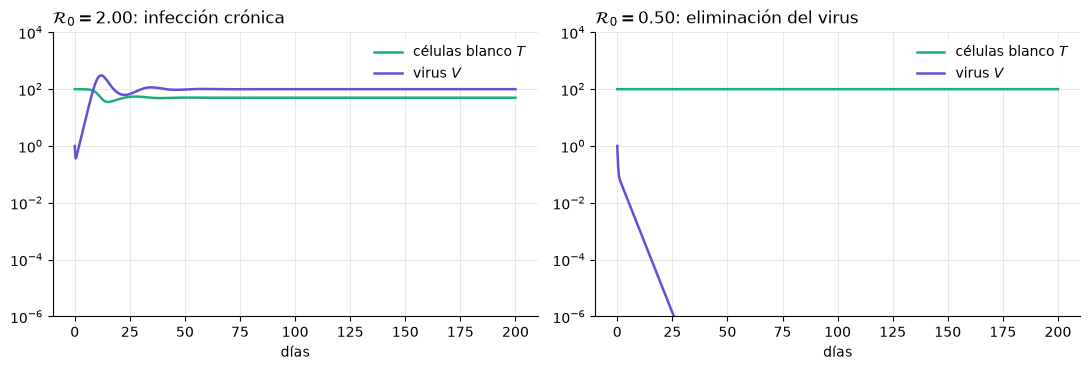

In [13]:
tiv = R0Model('''
    dT/dt = s - d*T - beta*T*V
    dI/dt = beta*T*V - delta*I
    dV/dt = p*I - c*V
''', infected=["I", "V"])
print("R0 =", tiv.R0)

vals = dict(s=10, d=0.1, beta=1e-3, delta=1, c=5)
cronica = tiv.simulate((0, 200), values=dict(vals, p=100), initial={"T": 100, "I": 0, "V": 1})
eliminada = tiv.simulate((0, 200), values=dict(vals, p=25), initial={"T": 100, "I": 0, "V": 1})

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, r, txt in [(axes[0], cronica, "infección crónica"), (axes[1], eliminada, "eliminación del virus")]:
    r.plot(["T", "V"], ax=ax, title=rf"$\mathcal{{R}}_0 = {r.R0:.2f}$: {txt}", logy=True, ylim=(1e-6, 1e4),
           labels={"T": "células blanco $T$", "V": "virus $V$"}, colors={"T": PALETTE[2], "V": PALETTE[6]},
           xlabel="días")
fig.savefig("outputs/06_tiv_carga_viral.png", dpi=200, bbox_inches="tight")

## 7. Modelo con linfocitos T helper (Cuesta-Herrera et al., 2025)

Con los valores de la Tabla 1 del artículo, $\mathcal{R}_0^* = 6030$ (Figura 3a), y con los de la Figura 3c, $\mathcal{R}_0^* = 19.89$. Si la producción basal de linfocitos T helper es alta ($b = 3\times 10^{7}$), entonces $T_{h0} = b/c$ aumenta la eliminación de células infectadas y de virus, y $\mathcal{R}_0^* < 1$. Partimos del DFE con 10 partículas virales.

Tabla 1        R0* = 6030.3030   V final = 9.236e+08


Figura 3c      R0* =   19.8920   V final = 3.525e+06
Th basal alta  R0* =    0.5419   V final = 2.106e-25


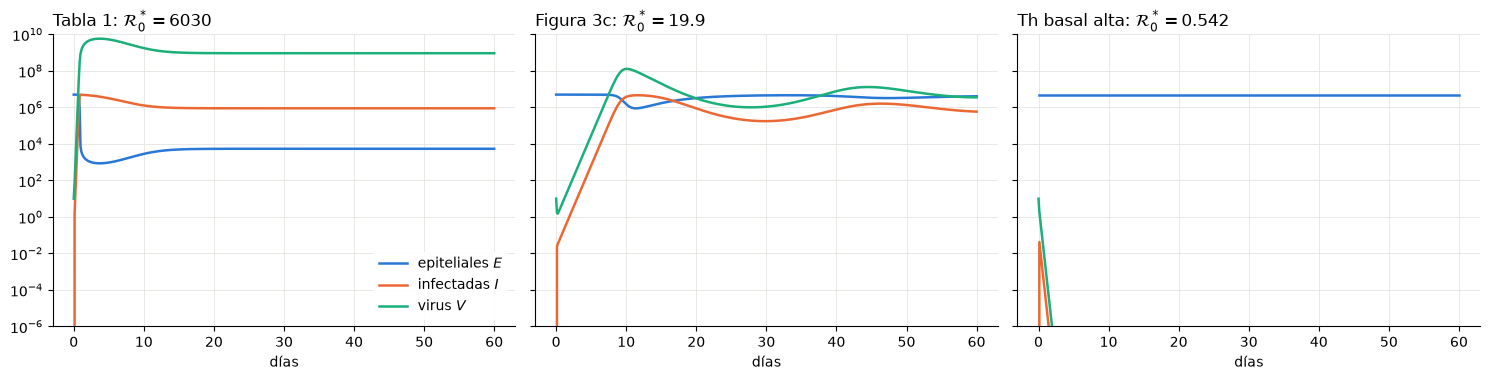

In [14]:
th = R0Model('''
    dE/dt  = lambda - d*E - kappa*E*V
    dI/dt  = kappa*E*V - alpha*I - beta*Th*I
    dV/dt  = nu*I - mu*V - tau*Th*V
    dTh/dt = b - c*Th + gamma*I*Th
''', infected=["I", "V"])

tabla1 = {"lambda": 5e5, "d": 0.1, "kappa": 1e-7, "alpha": 0.1, "beta": 1e-7, "nu": 995,
          "mu": 0.5, "tau": 1e-7, "b": 5e4, "c": 0.1, "gamma": 1e-7}
escenarios = {
    "Tabla 1": tabla1,
    "Figura 3c": dict(tabla1, **{"lambda": 1e6, "beta": 1.1e-7, "tau": 1e-4, "d": 0.2, "kappa": 1e-8, "b": 2e4}),
    "Th basal alta": dict(tabla1, b=3e7),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 3.9), sharey=True)
for ax, (nombre, vals) in zip(axes, escenarios.items()):
    inicio = {"E": vals["lambda"] / vals["d"], "I": 0, "V": 10, "Th": vals["b"] / vals["c"]}
    r = th.simulate((0, 60), values=vals, initial=inicio)
    print(f"{nombre:<14} R0* = {r.R0:9.4f}   V final = {r.final()['V']:.3e}")
    r0_txt = f"{r.R0:.0f}" if r.R0 >= 100 else f"{r.R0:.3g}"
    r.plot(["E", "I", "V"], ax=ax, title=nombre + r": $\mathcal{R}_0^* = $" + r0_txt,
           logy=True, ylim=(1e-6, 1e10), xlabel="días", legend=(ax is axes[0]),
           labels={"E": "epiteliales $E$", "I": "infectadas $I$", "V": "virus $V$"})
fig.savefig("outputs/06_modelo_Th_escenarios.png", dpi=200, bbox_inches="tight")

## 8. Un DFE sin forma cerrada: el lazo interferón, células NK y macrófagos

El modelo del cuaderno 04 tiene un bloque del DFE que no se resuelve simbólicamente a tiempo (`dfe_timeout`). `simulate()` usa el DFE numérico como condición inicial. Aquí se grafican variables seleccionadas en paneles separados, con títulos propios por panel. En este modelo la infección no estimula el lazo innato, así que $N$, $M$ y $F$ permanecen en su valor del DFE y no se grafican.

SimulationResult(1 run, R0 = 1.362, t in [0, 300]) | DFE inicial de N, M, F: {'N': 5.3148, 'M': 5.6562, 'F': 2.1995}


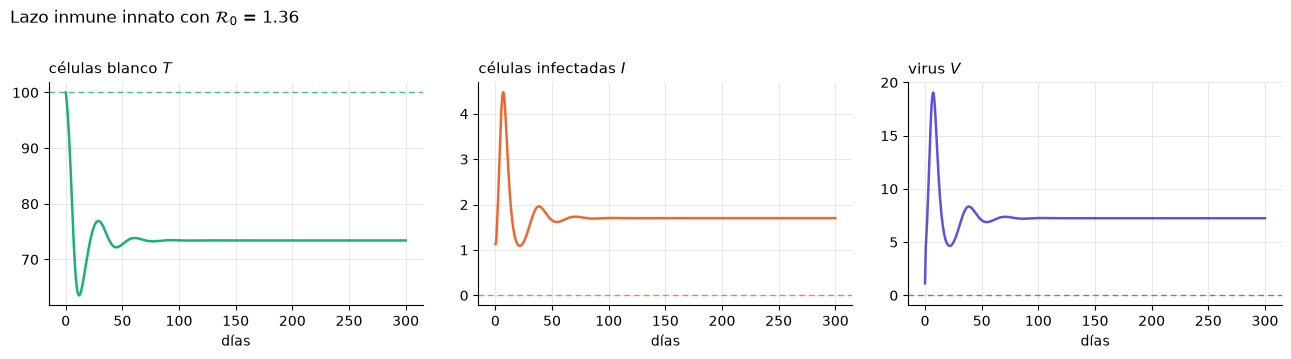

In [15]:
lazo = '''
    dT/dt = s - d_T*T - beta*T*V
    dI/dt = beta*T*V - (delta + k_N*N)*I
    dV/dt = p*I - (c + k_M*M)*V
    dN/dt = a_N - d_N*N + h_N*F^2/(F^2 + K_F^2)
    dM/dt = a_M - d_M*M + h_M*N/(N + K_N)
    dF/dt = a_F - d_F*F + h_F*M/(M + K_M)
'''
with warnings.catch_warnings():
    warnings.simplefilter("ignore")      # aviso de dfe_timeout: el bloque {N, M, F} queda implícito
    modelo_lazo = R0Model(lazo, infected=["I", "V"], dfe_timeout=5)

v_lazo = dict(s=10, d_T=0.1, beta=0.005, delta=0.5, k_N=0.2, p=20, c=3, k_M=0.3,
              a_N=1, d_N=0.5, h_N=2, K_F=1, a_M=1, d_M=0.4, h_M=1.5, K_N=1, a_F=0.5, d_F=1, h_F=2, K_M=1)
r = modelo_lazo.simulate((0, 300), values=v_lazo)
print(r, "| DFE inicial de N, M, F:", {k: round(r.initial[k], 4) for k in "NMF"})
r.plot(["T", "I", "V"], subplots=True, ncols=3, figsize=(13, 3.6), xlabel="días",
       title=r"Lazo inmune innato con $\mathcal{R}_0$ = {R0}",
       titles={"T": "células blanco $T$", "I": "células infectadas $I$", "V": "virus $V$"},
       colors=[PALETTE[2], PALETTE[1], PALETTE[6]], show_dfe=True,
       save="outputs/06_lazo_inmune_paneles.png");

Al aumentar la activación de NK por interferón ($h_N$), $\mathcal{R}_0$ baja de 1 y el virus se elimina:

SimulationResult(12 runs, R0 < 1 in 9, R0 > 1 in 3, t in [0, 300])


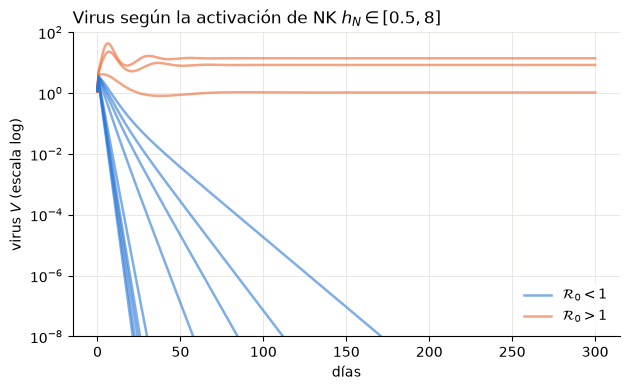

In [16]:
conjunto_lazo = modelo_lazo.simulate((0, 300), values={k: x for k, x in v_lazo.items() if k != "h_N"},
                                     ranges={"h_N": (0.5, 8)}, sampling="uniform", n_runs=12, seed=4)
print(conjunto_lazo)
conjunto_lazo.plot("V", logy=True, ylim=(1e-8, 1e2), xlabel="días", ylabel="virus $V$ (escala log)",
                   title=r"Virus según la activación de NK $h_N \in [0.5, 8]$",
                   save="outputs/06_lazo_inmune_conjunto.png");

## 9. Transmisión vectorial: Ross-Macdonald

Con humanos $S_h, I_h, R_h$ y vectores $S_v, I_v$, $\mathcal{R}_0$ es la raíz cuadrada del producto de las transmisiones humano→vector y vector→humano. Graficamos las prevalencias $I_h/N_h$ e $I_v/N_v$, en escala logarítmica, para tres valores de la tasa de picadura $a$. Con $\mathcal{R}_0 < 1$ la prevalencia decae desde el primer día. Con $\mathcal{R}_0 > 1$ hay un brote; después del pico la prevalencia cae porque el brote agota a los susceptibles humanos, que se reponen muy lentamente (esperanza de vida de 60 años). El equilibrio endémico, que existe porque $\mathcal{R}_0 > 1$, no se alcanza en esta ventana de dos años.

R0 = sqrt(Lambda_v)*a*sqrt(b)*sqrt(c)/(sqrt(N_h)*mu_v*sqrt(mu_h + r))


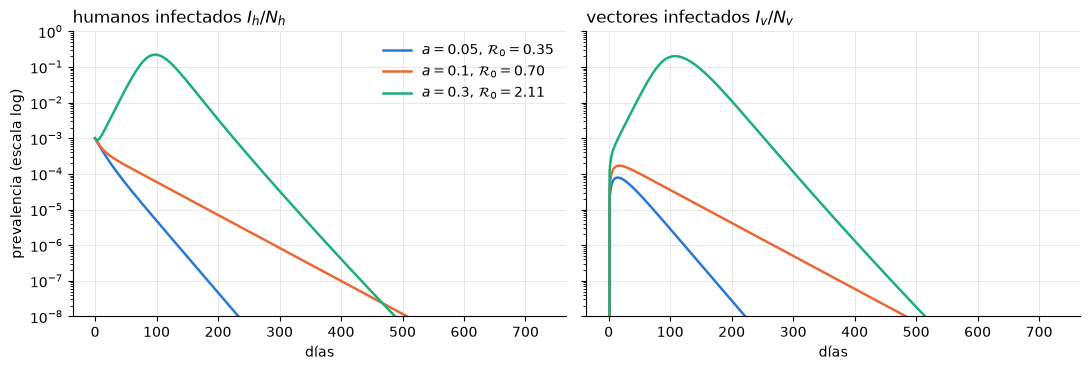

In [17]:
vector = R0Model('''
    dSh/dt = mu_h*N_h - a*b*Sh*Iv/N_h - mu_h*Sh
    dIh/dt = a*b*Sh*Iv/N_h - (r + mu_h)*Ih
    dRh/dt = r*Ih - mu_h*Rh
    dSv/dt = Lambda_v - a*c*Sv*Ih/N_h - mu_v*Sv
    dIv/dt = a*c*Sv*Ih/N_h - mu_v*Iv
''', infected=["Ih", "Iv"])
print("R0 =", vector.R0)

vv = dict(N_h=1000, mu_h=1 / (60 * 365), b=0.3, c=0.3, r=1 / 14, Lambda_v=200, mu_v=1 / 14)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for k, a in enumerate([0.05, 0.1, 0.3]):
    rv = vector.simulate((0, 730), values=dict(vv, a=a), initial={"Sh": 999, "Ih": 1, "Rh": 0, "Sv": 2800, "Iv": 0})
    lab = rf"$a = {a}$, $\mathcal{{R}}_0 = {rv.R0:.2f}$"
    axes[0].plot(rv.t, rv["Ih"] / vv["N_h"], color=PALETTE[k], linewidth=1.8, label=lab)
    axes[1].plot(rv.t, rv["Iv"] / (vv["Lambda_v"] / vv["mu_v"]), color=PALETTE[k], linewidth=1.8, label=lab)
for ax, txt in zip(axes, ["humanos infectados $I_h/N_h$", "vectores infectados $I_v/N_v$"]):
    ax.set_title(txt, loc="left")
    ax.set_yscale("log")
    ax.set_ylim(1e-8, 1)
    ax.set_xlabel("días")
    ax.grid(True, color="#e5e4e0", linewidth=0.6)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("prevalencia (escala log)")
axes[0].legend(frameon=False)
fig.tight_layout()
fig.savefig("outputs/06_ross_macdonald.png", dpi=200, bbox_inches="tight")

## 10. Los datos de las simulaciones

`to_dataframe()` entrega todas las simulaciones en formato largo (una fila por tiempo y simulación, con su $\mathcal{R}_0$), listo para exportar o analizar.

In [18]:
tabla = conjunto.to_dataframe()
tabla.to_csv("outputs/06_sir_conjunto.csv", index=False)
print(tabla.shape)
tabla.head()

(20000, 6)


,run,t,S,I,R,R0
0,0,0.000000,100.000000,1.000000,0.000000,0.772225
1,0,0.400802,99.823064,0.946540,0.191109,0.772225
2,0,0.801603,99.662847,0.895657,0.364465,0.772225
3,0,1.202405,99.518175,0.847270,0.521262,0.772225
4,0,1.603206,99.387944,0.801292,0.662634,0.772225


## Resumen

| Caso | Qué muestra |
|---|---|
| SIR con $\beta$ fijo | $\mathcal{R}_0 < 1$: vuelve al DFE; $\mathcal{R}_0 > 1$: equilibrio endémico |
| Parámetros aleatorios | `simulate()` sin `values`, reproducible con `seed` |
| Conjunto de simulaciones | parámetros fijos y aleatorios, coloreado por $\mathcal{R}_0$, plano de fase |
| `R0_range` | solo sorteos con $\mathcal{R}_0 > 1$ o $< 1$ |
| Barrido de $\beta$ | bifurcación transcrítica en $\mathcal{R}_0 = 1$ |
| Cerca del umbral | convergencia lenta cuando $\mathcal{R}_0 \to 1$ |
| SEIR con vacunación | escenarios en los mismos ejes; cobertura crítica $p_c = 1 - 1/\mathcal{R}_0$ |
| Intrahuésped TIV | infección crónica frente a eliminación del virus |
| Modelo con Th | escenarios del artículo y respuesta Th alta con $\mathcal{R}_0^* < 1$ |
| Lazo inmune innato | DFE sin forma cerrada; paneles por variable |
| Ross-Macdonald | $\mathcal{R}_0$ como raíz cuadrada; brote con $\mathcal{R}_0 > 1$ y decaimiento con $\mathcal{R}_0 < 1$ |

Todas las figuras y la tabla quedan en la carpeta `outputs/`.